# Identifikasi Tingkat Kata Kasar Berbahasa Indonesia dalam Platform Media Sosial Berbasis Teks

**Group 10 - LA01**  
- 2802403183 - Brian Nicholas Tedjo  
- 2802419446 - Jason Budiharjo  
- 2802402275 - Marvin Adriano Rusdianto

---

### Pipeline Overview
1. Data Loading & Exploration
2. Label Mapping (Kaggle labels → Level 0–3)
3. Preprocessing (7 steps)
4. Feature Extraction (Lexicon + TF-IDF)
5. Model Training: Logistic Regression, Naive Bayes, IndoBERT
6. Evaluation (F1-Score + Confusion Matrix)
7. Inference Demo

## Section 1: Setup & Installation

In [ ]:
# Run this cell once to install dependencies
# !pip install pandas numpy scikit-learn nltk PySastrawi rapidfuzz transformers torch matplotlib seaborn tqdm accelerate

In [20]:
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from rapidfuzz import fuzz, process

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Deep Learning
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print('All imports successful!')

All imports successful!


In [21]:
# ── Configuration ──────────────────────────────────────────────
DATA_PATH      = 'archive/data.csv'
ABUSIVE_PATH   = 'archive/abusive.csv'
SLANG_PATH     = 'archive/new_kamusalay.csv'
OUTPUT_PATH    = 'dataset_processed.csv'

INDOBERT_MODEL = 'indobenchmark/indobert-base-p1'

# Set MAX_SAMPLES to an integer (e.g. 3000) to limit data for faster testing.
# Set to None to use the full dataset.
MAX_SAMPLES    = None

MAX_LEN        = 128
BATCH_SIZE     = 16
EPOCHS         = 3
LEARNING_RATE  = 2e-5
RANDOM_STATE   = 42
TEST_SIZE      = 0.2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Section 2: Data Loading & Exploration

In [23]:
# Load main dataset
df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (13169, 13)


,Tweet,HS,Abusive,HS_Individual,HS_Group,HS_Religion,HS_Race,HS_Physical,HS_Gender,HS_Other,HS_Weak,HS_Moderate,HS_Strong
0,- disaat semua cowok berusaha melacak perhatia...,1,1,1,0,0,0,0,0,1,1,0,0
1,RT USER: USER siapa yang telat ngasih tau elu?...,0,1,0,0,0,0,0,0,0,0,0,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",0,0,0,0,0,0,0,0,0,0,0,0


In [24]:
print('Column types:')
print(df.dtypes)
print('\nNull values:')
print(df.isnull().sum())
print('\nHS distribution:', df['HS'].value_counts().to_dict())
print('Abusive distribution:', df['Abusive'].value_counts().to_dict())
print('HS_Weak:', df['HS_Weak'].value_counts().to_dict())
print('HS_Moderate:', df['HS_Moderate'].value_counts().to_dict())
print('HS_Strong:', df['HS_Strong'].value_counts().to_dict())

Column types:
Tweet              str
HS               int64
Abusive          int64
HS_Individual    int64
HS_Group         int64
HS_Religion      int64
HS_Race          int64
HS_Physical      int64
HS_Gender        int64
HS_Other         int64
HS_Weak          int64
HS_Moderate      int64
HS_Strong        int64
dtype: object

Null values:
Tweet            0
HS               0
Abusive          0
HS_Individual    0
HS_Group         0
HS_Religion      0
HS_Race          0
HS_Physical      0
HS_Gender        0
HS_Other         0
HS_Weak          0
HS_Moderate      0
HS_Strong        0
dtype: int64

HS distribution: {0: 7608, 1: 5561}
Abusive distribution: {0: 8126, 1: 5043}
HS_Weak: {0: 9786, 1: 3383}
HS_Moderate: {0: 11464, 1: 1705}
HS_Strong: {0: 12696, 1: 473}


In [26]:
# Load abusive word list (from dataset)
abusive_words_df = pd.read_csv(ABUSIVE_PATH)
abusive_word_list = abusive_words_df.iloc[:, 0].str.lower().dropna().tolist()
print(f'Abusive words in lexicon file: {len(abusive_word_list)}')
print('Sample:', abusive_word_list[:10])

# Load slang normalization dictionary
slang_df = pd.read_csv(SLANG_PATH, header=None, names=['slang', 'formal'], encoding='ISO-8859-1')
slang_dict = dict(zip(slang_df['slang'].str.lower(), slang_df['formal'].str.lower()))
print(f'\nSlang dictionary size: {len(slang_dict)}')
print('Sample slang entries:', list(slang_dict.items())[:5])

Abusive words in lexicon file: 125
Sample: ['alay', 'ampas', 'buta', 'keparat', 'anjing', 'anjir', 'babi', 'bacot', 'bajingan', 'banci']

Slang dictionary size: 15167
Sample slang entries: [('anakjakartaasikasik', 'anak jakarta asyik asyik'), ('pakcikdahtua', 'pak cik sudah tua'), ('pakcikmudalagi', 'pak cik muda lagi'), ('t3tapjokowi', 'tetap jokowi'), ('3x', 'tiga kali')]


## Section 3: Label Mapping

Mapping Kaggle dataset labels to 4-level profanity scale (Tabel 1):

| Level | Keterangan | Mapping |
|-------|------------|----------|
| 0 | Nihil | HS=0, Abusive=0 |
| 1 | Rendah | Abusive=1 or HS_Weak=1 |
| 2 | Menengah | HS_Moderate=1 |
| 3 | Tinggi | HS_Strong=1 |

Level distribution:
  Level 0 (Nihil): 5,860 (44.5%)
  Level 1 (Rendah): 5,131 (39.0%)
  Level 2 (Menengah): 1,705 (12.9%)
  Level 3 (Tinggi): 473 (3.6%)


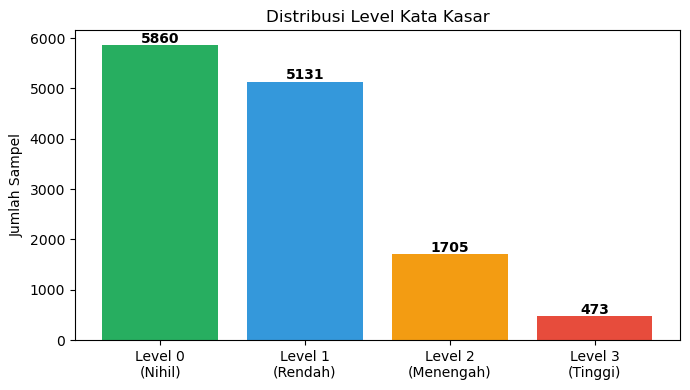

In [27]:
def map_to_level(row):
    """Map Kaggle hate speech labels to 0-3 profanity level scale."""
    if row['HS'] == 0 and row['Abusive'] == 0:
        return 0  # Nihil
    elif row['HS_Strong'] == 1:
        return 3  # Tinggi
    elif row['HS_Moderate'] == 1:
        return 2  # Menengah
    else:
        return 1  # Rendah (HS_Weak or Abusive)

df['Level Kata Kasar'] = df.apply(map_to_level, axis=1)

print('Level distribution:')
level_counts = df['Level Kata Kasar'].value_counts().sort_index()
for level, count in level_counts.items():
    label = {0: 'Nihil', 1: 'Rendah', 2: 'Menengah', 3: 'Tinggi'}[level]
    print(f'  Level {level} ({label}): {count:,} ({count/len(df)*100:.1f}%)')

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#27ae60', '#3498db', '#f39c12', '#e74c3c']
labels = ['Level 0\n(Nihil)', 'Level 1\n(Rendah)', 'Level 2\n(Menengah)', 'Level 3\n(Tinggi)']
ax.bar(labels, level_counts.values, color=colors)
ax.set_title('Distribusi Level Kata Kasar')
ax.set_ylabel('Jumlah Sampel')
for i, v in enumerate(level_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4: Preprocessing Pipeline

7-step preprocessing pipeline sesuai proposal:
1. **Deteksi Penyamaran** – RegEx `[0-9@!$.|]`
2. **Lowercasing** – `.lower()`
3. **Penghapusan spasi berlebih** – gabungkan karakter yang dipisah spasi
4. **Pembersihan tanda baca** – hapus `.`, `-`, `_`, `'`, `;`, `"`
5. **Substitusi leet speak** – konversi angka/simbol ke huruf
6. **Tokenisasi** – `word_tokenize`
7. **Stemming** – PySastrawi

In [28]:
# ── Initialize PySastrawi ──────────────────────────────────────
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopword_list = set(stopword_factory.get_stop_words())

# ── Leet speak substitution map ───────────────────────────────
LEET_MAP = {
    '0': 'o', '1': 'i', '2': 'z', '3': 'e', '4': 'a',
    '5': 's', '6': 'g', '7': 't', '8': 'b', '9': 'g',
    '@': 'a', '!': 'i', '$': 's',
}

# ── Preprocessing functions ────────────────────────────────────

def detect_disguise(text: str) -> int:
    """Step 1: Flag text that contains leet-speak characters."""
    return 1 if re.search(r'[0-9@!$.|]', str(text)) else 0


def lowercase(text: str) -> str:
    """Step 2: Lowercase."""
    return str(text).lower()


def remove_excessive_spaces(text: str) -> str:
    """
    Step 3: Collapse spaced-out characters.
    'a n j i n g' -> 'anjing'
    """
    def join_match(m):
        return m.group(0).replace(' ', '')
    return re.sub(r'(?<!\w)(\w\s){2,}\w(?!\w)', join_match, text)


def clean_punctuation(text: str) -> str:
    """
    Step 4: Remove punctuation that rarely substitutes letters.
    Keeps *, !, @ (common in disguised profanity).
    """
    return re.sub(r'(?<=[a-z])[.\-_\';"\u201c\u201d](?=[a-z])', '', text)


def substitute_leet(text: str) -> str:
    """Step 5: Convert leet-speak characters back to letters."""
    return ''.join(LEET_MAP.get(c, c) for c in text)


def normalize_slang(tokens: list, slang_dict: dict) -> list:
    """Normalize slang words using kamusalay dictionary."""
    normalized = []
    for token in tokens:
        formal = slang_dict.get(token, token)
        # slang may map to multi-word phrase; split and add all
        normalized.extend(formal.split())
    return normalized


def tokenize(text: str) -> list:
    """Step 6: Tokenize using NLTK word_tokenize."""
    return word_tokenize(text)


def stem_tokens(tokens: list) -> list:
    """Step 7: Stem with PySastrawi."""
    return [stemmer.stem(t) for t in tokens]


def preprocess(text: str, for_bert: bool = False) -> str:
    """
    Full preprocessing pipeline.
    for_bert=True  → skip tokenization & stemming (BERT has its own tokenizer).
    for_bert=False → return stemmed, space-joined token string for TF-IDF.
    """
    text = lowercase(text)                  # step 2
    text = remove_excessive_spaces(text)    # step 3
    text = clean_punctuation(text)          # step 4
    text = substitute_leet(text)            # step 5
    # Remove remaining non-alphanumeric characters (except spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if for_bert:
        return text  # return as clean string; BERT uses AutoTokenizer

    tokens = tokenize(text)                         # step 6
    tokens = [t for t in tokens if t.isalpha()]     # drop punctuation tokens
    tokens = normalize_slang(tokens, slang_dict)    # slang normalization
    tokens = stem_tokens(tokens)                    # step 7

    return ' '.join(tokens)


# Quick sanity check
test_cases = [
    "a n j i n g kamu!",
    "d4s4r b4ngs4t",
    "Hari ini cuaca cerah sekali.",
    "dasar b@ngs@t lu!",
]
print('Preprocessing sanity check:')
for t in test_cases:
    print(f'  Original : {t}')
    print(f'  For ML   : {preprocess(t, for_bert=False)}')
    print(f'  For BERT : {preprocess(t, for_bert=True)}')
    print()

Preprocessing sanity check:
  Original : a n j i n g kamu!
  For ML   : anjing kamu
  For BERT : anjing kamui

  Original : d4s4r b4ngs4t
  For ML   : dasar bangsat
  For BERT : dasar bangsat

  Original : Hari ini cuaca cerah sekali.
  For ML   : hari ini cuaca cerah sekali
  For BERT : hari ini cuaca cerah sekali

  Original : dasar b@ngs@t lu!
  For ML   : dasar bangsat lui
  For BERT : dasar bangsat lui



In [29]:
# Apply to dataset
print('Running preprocessing (this may take a few minutes)...')

# Keep original tweet
df['Kalimat Asli'] = df['Tweet'].astype(str)

# Step 1: Disguise detection on RAW text (before any cleaning)
df['Disamarkan'] = df['Kalimat Asli'].apply(detect_disguise)

# Preprocessed for traditional ML (with stemming)
tqdm.pandas(desc='Preprocessing for ML')
df['Kalimat Dinormalisasi'] = df['Kalimat Asli'].progress_apply(
    lambda x: preprocess(x, for_bert=False)
)

# Preprocessed for IndoBERT (without stemming)
tqdm.pandas(desc='Preprocessing for BERT')
df['Kalimat Bert'] = df['Kalimat Asli'].progress_apply(
    lambda x: preprocess(x, for_bert=True)
)

print('\nPreprocessing done!')
df[['Kalimat Asli', 'Kalimat Dinormalisasi', 'Level Kata Kasar', 'Disamarkan']].head(5)

Running preprocessing (this may take a few minutes)...


Preprocessing for BERT: 100%|██████████| 13169/13169 [00:00<00:00, 48883.42it/s]


Preprocessing done!


,Kalimat Asli,Kalimat Dinormalisasi,Level Kata Kasar,Disamarkan
0,- disaat semua cowok berusaha melacak perhatia...,di saat semua cowok usaha lacak perhati gue ka...,1,1
1,RT USER: USER siapa yang telat ngasih tau elu?...,rt guna guna siapa yang telat beri tau kamu ed...,1,0
2,"41. Kadang aku berfikir, kenapa aku tetap perc...",ai kadang aku pikir kenapa aku tetap percaya p...,0,1
3,USER USER AKU ITU AKU\n\nKU TAU MATAMU SIPIT T...,guna guna aku itu aku dan ku tau mata sipit ta...,0,0
4,USER USER Kaum cebong kapir udah keliatan dong...,guna guna kaum cebong kafir sudah lihat dongok...,2,0


In [30]:
# Save processed dataset (format sesuai proposal)
df_out = df[['Kalimat Asli', 'Kalimat Dinormalisasi', 'Level Kata Kasar', 'Disamarkan']].copy()
df_out.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
print(f'Saved processed dataset → {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
print(f'Disguised sentences: {df["Disamarkan"].sum():,} ({df["Disamarkan"].mean()*100:.1f}%)')

Saved processed dataset → dataset_processed.csv
Shape: (13169, 4)
Disguised sentences: 8,831 (67.1%)


## Section 5: Lexicon Kata Kasar

Lexicon berisi kata-kata kasar dengan level kekasarannya.  
Kata-kata dengan makna ganda (`anjing`, `gila`, `edan`, `babi`) **tidak** dimasukkan ke lexicon — ditangani secara kontekstual oleh IndoBERT.

In [31]:
# ── Profanity Lexicon ─────────────────────────────────────────
LEXICON = {
    # Level 1 – Rendah
    'bego': 1, 'goblok': 1, 'tolol': 1, 'idiot': 1, 'bodoh': 1,
    'dungu': 1, 'sinting': 1, 'kampungan': 1, 'pekok': 1, 'geblek': 1,
    'gendeng': 1, 'edyan': 1, 'cungkring': 1, 'telmi': 1, 'dodol': 1,
    'bloon': 1, 'blo on': 1, 'kurang waras': 1,

    # Level 2 – Menengah
    'bangsat': 2, 'bajingan': 2, 'brengsek': 2, 'keparat': 2, 'sialan': 2,
    'kampret': 2, 'celaka': 2, 'bedebah': 2, 'sundel': 2, 'setan': 2,
    'iblis': 2, 'tai': 2, 'taik': 2, 'tai kucing': 2, 'kurang ajar': 2,
    'biadab': 2, 'laknat': 2, 'terkutuk': 2, 'mampus': 2, 'brengsek': 2,

    # Level 3 – Tinggi
    'jancok': 3, 'jancuk': 3, 'kontol': 3, 'memek': 3, 'dancok': 3,
    'lonte': 3, 'pelacur': 3, 'sundal': 3, 'bejat': 3, 'monyet': 3,
    'kimak': 3, 'pukimak': 3, 'ngentot': 3, 'coli': 3, 'ngentod': 3,
    'entot': 3, 'asu': 3, 'asem': 3, 'bajingan': 3,
}

# Words with ambiguous meaning — handled by IndoBERT contextually
AMBIGUOUS_WORDS = {'anjing', 'gila', 'edan', 'babi', 'kampung', 'jawa', 'brengsek'}


def lexicon_match(text: str, threshold: int = 85) -> int:
    """
    Match preprocessed text tokens against LEXICON using exact + fuzzy matching.
    Returns the highest profanity level found (0 if none).
    RapidFuzz is used for detecting disguised/modified profanity.
    """
    if not text or not isinstance(text, str):
        return 0

    tokens = text.split()
    max_level = 0

    for token in tokens:
        if token in AMBIGUOUS_WORDS:
            continue  # let IndoBERT handle context-dependent words

        # Exact match first (fast)
        if token in LEXICON:
            max_level = max(max_level, LEXICON[token])
            continue

        # Fuzzy match with RapidFuzz (catches disguised/modified words)
        result = process.extractOne(token, LEXICON.keys(), scorer=fuzz.ratio)
        if result and result[1] >= threshold:
            max_level = max(max_level, LEXICON[result[0]])

    return max_level


# Test lexicon matching
test_words = [
    ('tolol banget sih', 'exact match level 1'),
    ('d4s4r b4ngsat', 'leet speak level 2 — after preprocessing'),
    ('hari ini cerah', 'no profanity'),
    ('anjing saya sakit', 'ambiguous — should be 0 from lexicon'),
]
print('Lexicon match test:')
for text, desc in test_words:
    pre = preprocess(text, for_bert=False)
    level = lexicon_match(pre)
    print(f'  [{desc}]')
    print(f'    Input: "{text}" → preprocessed: "{pre}" → Level: {level}')

print(f'\nTotal lexicon entries: {len(LEXICON)}')

Lexicon match test:
  [exact match level 1]
    Input: "tolol banget sih" → preprocessed: "tolol banget sih" → Level: 1
  [leet speak level 2 — after preprocessing]
    Input: "d4s4r b4ngsat" → preprocessed: "dasar bangsat" → Level: 2
  [no profanity]
    Input: "hari ini cerah" → preprocessed: "hari ini cerah" → Level: 0
  [ambiguous — should be 0 from lexicon]
    Input: "anjing saya sakit" → preprocessed: "anjing saya sakit" → Level: 0

Total lexicon entries: 55


## Section 6: Feature Extraction & Train/Test Split

In [32]:
# Drop rows with empty preprocessed text
df_clean = df.dropna(subset=['Kalimat Dinormalisasi', 'Kalimat Bert']).copy()
df_clean = df_clean[
    (df_clean['Kalimat Dinormalisasi'].str.strip() != '') &
    (df_clean['Kalimat Bert'].str.strip() != '')
].reset_index(drop=True)

# Optional: limit dataset size for faster testing
if MAX_SAMPLES is not None:
    df_clean = df_clean.sample(n=min(MAX_SAMPLES, len(df_clean)),
                               random_state=RANDOM_STATE).reset_index(drop=True)

X_ml   = df_clean['Kalimat Dinormalisasi']  # for LR + NB
X_bert = df_clean['Kalimat Bert']           # for IndoBERT
y      = df_clean['Level Kata Kasar']

print(f'Total samples: {len(df_clean):,}')
print(f'Label distribution:\n{y.value_counts().sort_index()}')

# ── Train / Test Split ────────────────────────────────────────
# Split indices once, reuse for all three models
(X_train_ml,  X_test_ml,
 X_train_bert, X_test_bert,
 y_train,      y_test) = train_test_split(
    X_ml, X_bert, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'\nTrain: {len(y_train):,} | Test: {len(y_test):,}')

# ── TF-IDF Vectorizers ────────────────────────────────────────
# Logistic Regression: character n-gram (2-5), as per proposal
tfidf_lr = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 5),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True,
)

# Naive Bayes: word n-gram (1-2)
tfidf_nb = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=50_000,
    min_df=2,
    sublinear_tf=True,
)

X_train_lr = tfidf_lr.fit_transform(X_train_ml)
X_test_lr  = tfidf_lr.transform(X_test_ml)

X_train_nb = tfidf_nb.fit_transform(X_train_ml)
X_test_nb  = tfidf_nb.transform(X_test_ml)

print(f'\nTF-IDF (LR) shape: {X_train_lr.shape}')
print(f'TF-IDF (NB) shape: {X_train_nb.shape}')

Total samples: 13,169
Label distribution:
Level Kata Kasar
0    5860
1    5131
2    1705
3     473
Name: count, dtype: int64

Train: 10,535 | Test: 2,634

TF-IDF (LR) shape: (10535, 38893)
TF-IDF (NB) shape: (10535, 27616)


## Section 7: Model 1 – Logistic Regression

Logistic Regression dengan representasi fitur TF-IDF character n-gram.

In [34]:
print('Training Logistic Regression...')

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    random_state=RANDOM_STATE,
    class_weight='balanced',
)
lr_model.fit(X_train_lr, y_train)

y_pred_lr = lr_model.predict(X_test_lr)
f1_lr = f1_score(y_test, y_pred_lr, average='macro')

print(f'\nLogistic Regression – F1-Score (macro): {f1_lr:.4f}')
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']
))

Training Logistic Regression...

Logistic Regression – F1-Score (macro): 0.7320

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.87      0.83      0.85      1172
     Level 1       0.80      0.75      0.77      1026
     Level 2       0.51      0.63      0.56       341
     Level 3       0.64      0.87      0.74        95

    accuracy                           0.77      2634
   macro avg       0.71      0.77      0.73      2634
weighted avg       0.79      0.77      0.78      2634



## Section 8: Model 2 – Naive Bayes

Complement Naive Bayes (lebih baik dari Multinomial NB untuk dataset imbalanced).

In [35]:
print('Training Naive Bayes...')

# ComplementNB performs better on imbalanced multi-class text data
nb_model = ComplementNB(alpha=0.1)
nb_model.fit(X_train_nb, y_train)

y_pred_nb = nb_model.predict(X_test_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='macro')

print(f'\nNaive Bayes – F1-Score (macro): {f1_nb:.4f}')
print('\nClassification Report:')
print(classification_report(
    y_test, y_pred_nb,
    target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']
))

Training Naive Bayes...

Naive Bayes – F1-Score (macro): 0.6805

Classification Report:
              precision    recall  f1-score   support

     Level 0       0.82      0.80      0.81      1172
     Level 1       0.72      0.79      0.76      1026
     Level 2       0.53      0.40      0.46       341
     Level 3       0.69      0.72      0.70        95

    accuracy                           0.74      2634
   macro avg       0.69      0.68      0.68      2634
weighted avg       0.74      0.74      0.74      2634



## Section 9: Model 3 – IndoBERT

IndoBERT (`indobenchmark/indobert-base-p1`) di-fine-tune untuk klasifikasi 4 kelas.

> **Catatan:** Fine-tuning di CPU membutuhkan waktu lebih lama. Kurangi `MAX_SAMPLES` atau `EPOCHS` untuk mempercepat pengujian.

In [ ]:
class ProfanityDataset(Dataset):
    """PyTorch Dataset for IndoBERT fine-tuning."""

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
print(f'Loading IndoBERT tokenizer & model from: {INDOBERT_MODEL}')

bert_tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    INDOBERT_MODEL,
    num_labels=4,
    ignore_mismatched_sizes=True,
)
bert_model = bert_model.to(device)

print(f'Model loaded! Parameters: {sum(p.numel() for p in bert_model.parameters()):,}')

In [ ]:
train_dataset = ProfanityDataset(
    X_train_bert.reset_index(drop=True),
    y_train.reset_index(drop=True),
    bert_tokenizer
)
test_dataset = ProfanityDataset(
    X_test_bert.reset_index(drop=True),
    y_test.reset_index(drop=True),
    bert_tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

In [ ]:
# ── Optimizer & Scheduler ──────────────────────────────────────
optimizer = AdamW(bert_model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps,
)


def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    for batch in tqdm(loader, desc='  Training', leave=False):
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['labels'].to(device),
        )
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += out.loss.item()
    return total_loss / len(loader)


def evaluate_bert(model, loader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='  Evaluating', leave=False):
            out = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
            )
            preds.extend(torch.argmax(out.logits, dim=1).cpu().numpy())
            trues.extend(batch['labels'].numpy())
    return np.array(preds), np.array(trues)


# ── Training Loop ──────────────────────────────────────────────
print(f'Fine-tuning IndoBERT for {EPOCHS} epoch(s) on {device}...\n')
history = []

for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(bert_model, train_loader, optimizer, scheduler, device)
    y_pred_ep, y_true_ep = evaluate_bert(bert_model, test_loader, device)
    ep_f1 = f1_score(y_true_ep, y_pred_ep, average='macro')
    history.append({'epoch': epoch, 'loss': avg_loss, 'f1': ep_f1})
    print(f'Epoch {epoch}/{EPOCHS}  |  Loss: {avg_loss:.4f}  |  F1 (macro): {ep_f1:.4f}')

# Final evaluation
y_pred_bert, y_true_bert = evaluate_bert(bert_model, test_loader, device)
f1_bert = f1_score(y_true_bert, y_pred_bert, average='macro')

print(f'\nIndoBERT – F1-Score (macro): {f1_bert:.4f}')
print('\nClassification Report:')
print(classification_report(
    y_true_bert, y_pred_bert,
    target_names=['Level 0', 'Level 1', 'Level 2', 'Level 3']
))

In [ ]:
# Plot training history
hist_df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(hist_df['epoch'], hist_df['loss'], marker='o', color='#e74c3c')
ax1.set_title('IndoBERT Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax2.plot(hist_df['epoch'], hist_df['f1'], marker='o', color='#3498db')
ax2.set_title('IndoBERT F1-Score per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
plt.tight_layout()
plt.savefig('bert_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Evaluasi & Perbandingan Model

In [ ]:
def plot_cm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['L0', 'L1', 'L2', 'L3'],
        yticklabels=['L0', 'L1', 'L2', 'L3'],
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_cm(y_test,      y_pred_lr,   f'Logistic Regression\nF1={f1_lr:.4f}',  axes[0])
plot_cm(y_test,      y_pred_nb,   f'Naive Bayes\nF1={f1_nb:.4f}',          axes[1])
plot_cm(y_true_bert, y_pred_bert, f'IndoBERT\nF1={f1_bert:.4f}',           axes[2])
plt.suptitle('Confusion Matrices – Perbandingan Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Summary Table ─────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

def get_metrics(y_true, y_pred):
    return {
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 (macro)':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_test,      y_pred_lr),
    'Naive Bayes':         get_metrics(y_test,      y_pred_nb),
    'IndoBERT':            get_metrics(y_true_bert, y_pred_bert),
}).T.round(4)

print('=== Model Comparison ===\n')
print(results.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
w = 0.25
bars1 = ax.bar(x - w, results['Precision (macro)'], w, label='Precision', color='#3498db')
bars2 = ax.bar(x,     results['Recall (macro)'],    w, label='Recall',    color='#2ecc71')
bars3 = ax.bar(x + w, results['F1 (macro)'],        w, label='F1 (macro)',color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(results.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model', fontweight='bold')
ax.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 11: Inference Demo

Fungsi prediksi yang menggabungkan lexicon matching + IndoBERT classification.

In [ ]:
LEVEL_LABELS = {
    0: 'Nihil (Tidak ada kata kasar)',
    1: 'Rendah (Mild profanity)',
    2: 'Menengah (Moderate profanity)',
    3: 'Tinggi (Severe/Explicit profanity)',
}


def predict(text: str, verbose: bool = True) -> dict:
    """
    Predict the profanity level of an Indonesian text.

    Pipeline:
      1. Detect if text contains disguised characters.
      2. Preprocess.
      3. Lexicon match (with RapidFuzz fuzzy matching).
      4. IndoBERT contextual classification.
    """
    disguised   = detect_disguise(text)
    prep_ml     = preprocess(text, for_bert=False)
    prep_bert   = preprocess(text, for_bert=True)
    lex_level   = lexicon_match(prep_ml)

    # IndoBERT prediction
    bert_model.eval()
    enc = bert_tokenizer(
        prep_bert,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt',
    )
    with torch.no_grad():
        logits = bert_model(
            input_ids=enc['input_ids'].to(device),
            attention_mask=enc['attention_mask'].to(device),
        ).logits

    probs      = torch.softmax(logits, dim=1)[0].cpu().numpy()
    bert_level = int(np.argmax(probs))
    confidence = float(probs[bert_level])

    result = {
        'input':           text,
        'disguised':       bool(disguised),
        'preprocessed':    prep_ml,
        'lexicon_level':   lex_level,
        'bert_level':      bert_level,
        'confidence':      confidence,
        'probabilities':   {f'L{i}': round(float(p), 4) for i, p in enumerate(probs)},
    }

    if verbose:
        print(f'Input       : {text}')
        print(f'Disguised   : {result["disguised"]}')
        print(f'Preprocessed: {prep_ml}')
        print(f'Lexicon     : Level {lex_level} – {LEVEL_LABELS[lex_level]}')
        print(f'IndoBERT    : Level {bert_level} – {LEVEL_LABELS[bert_level]}  (confidence: {confidence:.1%})')
        print(f'Probs       : {result["probabilities"]}')
        print()

    return result

In [ ]:
print('=' * 60)
print('INFERENCE DEMO')
print('=' * 60)

test_sentences = [
    # Level 0 – no profanity
    'Hari ini cuaca sangat cerah dan menyenangkan.',
    'Saya pergi ke sekolah bersama teman-teman.',

    # Level 0 – ambiguous words in neutral context (IndoBERT should catch this)
    'Anjing saya sakit dan harus ke dokter hewan.',
    'Gila, pemandangannya indah sekali!',

    # Level 1 – mild profanity
    'Duh, tolol banget sih kamu ini.',
    'Goblok amat, masa gitu aja salah!',

    # Level 2 – moderate profanity
    'Dasar bajingan, berani-beraninya kamu!',
    'Sialan banget kelakuan kamu tuh.',

    # Level 3 – severe, with disguise
    'd4s4r j4nc0k kamu!',
    'a n j i n g, kontol banget sih!',
]

for sentence in test_sentences:
    print('-' * 60)
    predict(sentence, verbose=True)

In [ ]:
# ── Interactive Prediction ─────────────────────────────────────
# Uncomment and modify the text below to test your own inputs

# user_text = "Tulis kalimat yang ingin diuji di sini"
# result = predict(user_text)
# print(f"Final Level: {result['bert_level']}")

## Section 12: Save Model (Optional)

In [36]:
import pickle

# Save traditional ML models + vectorizers
os.makedirs('saved_models', exist_ok=True)

with open('saved_models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
with open('saved_models/lr_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf_lr, f)
with open('saved_models/nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
with open('saved_models/nb_tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf_nb, f)

# Save IndoBERT fine-tuned model
# bert_model.save_pretrained('saved_models/indobert_finetuned')
# bert_tokenizer.save_pretrained('saved_models/indobert_finetuned')

print('All models saved to saved_models/')
print('  lr_model.pkl        – Logistic Regression')
print('  lr_tfidf.pkl        – TF-IDF vectorizer for LR')
print('  nb_model.pkl        – Naive Bayes')
print('  nb_tfidf.pkl        – TF-IDF vectorizer for NB')
print('  indobert_finetuned/ – Fine-tuned IndoBERT')

All models saved to saved_models/
  lr_model.pkl        – Logistic Regression
  lr_tfidf.pkl        – TF-IDF vectorizer for LR
  nb_model.pkl        – Naive Bayes
  nb_tfidf.pkl        – TF-IDF vectorizer for NB
  indobert_finetuned/ – Fine-tuned IndoBERT
